In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()  # picks up GROQ_API_KEY and LANGSMITH_* tracing vars from .env

In [1]:
print("hello")

hello


In [3]:
#router will decide the routing to the next node 

import os 
api_key=os.getenv("GROQ_API_KEY")
if api_key:
    print("API key found")
else:
    print("API key not found")

API key found


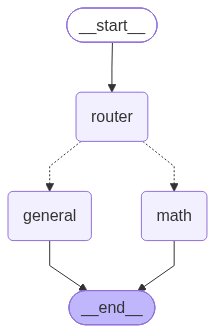

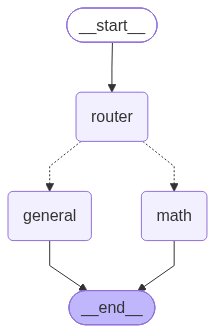

In [5]:
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from langgraph.graph import START, END, StateGraph
from IPython.display import display,Image

class State(TypedDict):
    question: str
    result: str

def router(state: State) -> Literal["math","general"]:

    question=state["question"].lower()
    if any(word in question for word in ["calculate", "add", "multiply", "divide"]):
        return "math"

    return "general"

def math_node(state: State)-> str:
    return "This should be a math node work"

def general_node(state: State)-> str:
    return "This should be a general node work"

builder=StateGraph(State)

builder.add_node("router", lambda state: state)
builder.add_node("math", math_node)
builder.add_node("general",general_node)

builder.add_edge(START,"router")
builder.add_conditional_edges(
    "router",
    router,
    {
        "math": "math",
        "general": "general"
    }
)
builder.add_edge("math", END)
builder.add_edge("general", END)
graph=builder.compile();
display(graph)
Image(graph.get_graph().draw_mermaid_png())



In [9]:
from pydantic import BaseModel, Field
from typing import Literal
class StructuredSchema(BaseModel):
    category: Literal['insta','twitter','linkedIn']=Field(..., description="Category of the social media platform")
    topic: str=Field(..., description="Topic of the social media content")

llm=ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
    model="openai/gpt-oss-120b"
)
llm_with_schema=llm.with_structured_output(StructuredSchema)

llm_with_schema.invoke("I want to generate a post for twitter about AI").category

'twitter'